# **Lesson_6.1**

## In this lecture

* Fork repository

* Decision tree
* In-class exercise

---

## Decision Tree ML model

A **decision tree** (in simple words) represents a hierarchical series of binary decisions:

<p align="center">
	<img src="../assets/img/decision_tree.jpg" width="600">
</p>

* A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually

## Who would survive on Titanic?
<p align="center">
	<img src='../assets/img/decision_tree_titanic.jpg' width = '500'>
</p>

#### Import libraries and modules

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree, export_text
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools


#### Load Titanic dataset

In [10]:
# We use url, but can also download and access it locally
dataset_path = 'https://raw.githubusercontent.com/Koldim2001/test_api/refs/heads/main/titanic.csv' 
df = pd.read_csv(dataset_path)

#### Let's have a look at the dataset

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Select features
* We only select `Pclass`, `Age` and `Fare` features for the sake of demonstration of the model
* Maximising model prediction accuracy was not a goal of the present exercise
* In particular, we do not *one-hot* encode categorical features. Feel free to add hot-encoded features and see how prediction accuracy can be affected
* `Survived` column will be our **target**

In [14]:
df = df[['Survived', 'Pclass', 'Age', 'Fare']]  # The subset (columns) we selected for this project
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       714 non-null    float64
 3   Fare      891 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


#### Data cleaning: drop lines where `Age`data are not available

In [15]:
df = df.dropna(subset=['Age'])

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  714 non-null    int64  
 1   Pclass    714 non-null    int64  
 2   Age       714 non-null    float64
 3   Fare      714 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 27.9 KB


In [17]:
df.isna().sum()

Survived    0
Pclass      0
Age         0
Fare        0
dtype: int64

In [18]:
df.drop(columns='Survived')  # These are our features

,Pclass,Age,Fare
0,3,22.0,7.2500
1,1,38.0,71.2833
2,3,26.0,7.9250
3,1,35.0,53.1000
4,3,35.0,8.0500
...,...,...,...
885,3,39.0,29.1250
886,2,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


#### Split dataset

In [19]:
# Splitdataset
train, test = train_test_split(df, test_size=0.2)

#### Build a helper function to plot Confusion Matrix

In [20]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    Plots confusion matrix
    cm - confusion matrix
    classes - class list
    normalize - normalize to 1 if True
    title - plot title
    cmap - color map
    """

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

#### Helper function to build and train Decision Tree model

In [21]:
def experiment(max_depth, min_samples_split):
    """
    Builds and trains Decision Tree model
    """
    # Build and train Decision Tree model
    model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
    model.fit(train.drop('Survived', axis=1), train['Survived'])

    # Calculate accuracy metrics
    preds = model.predict(test.drop('Survived', axis=1))
    acc = accuracy_score(test['Survived'], preds)
    cm = confusion_matrix(test['Survived'], preds)

    print("accuracy", acc)

    # Plot confusion matrix
    plot_confusion_matrix(cm, classes=['Not Survived', 'Survived'])

    # Classification report
    report = classification_report(test['Survived'], preds, target_names=['Not Survived', 'Survived'])
    print(report)

    # Save model in pickle format
    with open('../models/model_dt.pkl', 'wb') as f:
        pickle.dump(model, f)
        

#### Define model <u>hyperparameters</u>

In [22]:
# Define model hyperparameters
max_depth = 5
min_samples_split = 150


accuracy 0.6993006993006993
Confusion matrix, without normalization
              precision    recall  f1-score   support

Not Survived       0.67      0.85      0.75        75
    Survived       0.77      0.53      0.63        68

    accuracy                           0.70       143
   macro avg       0.72      0.69      0.69       143
weighted avg       0.71      0.70      0.69       143



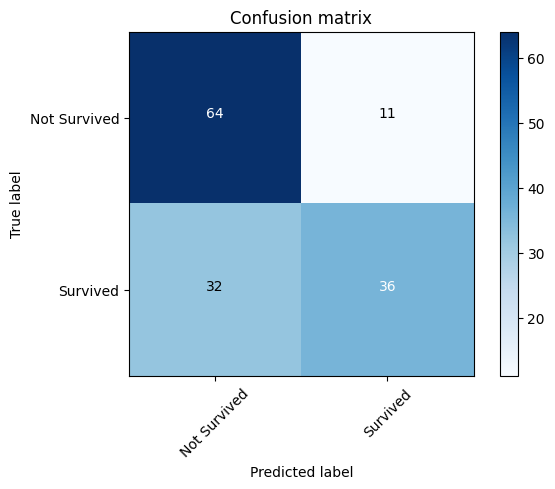

In [23]:
experiment(max_depth, min_samples_split)

#### Prediction for a single person

In [24]:
with open('../models/model_dt.pkl', 'rb') as f:
    model = pickle.load(f)

In [25]:
# Predict outcome of Titanic trip for a person
person = pd.DataFrame({
	'Pclass':[3],
	'Age':[55],
	'Fare':[7.2500]	
})

prediction = model.predict(person)
print(f"The model predicts {prediction}")

The model predicts [0]


In [26]:
if prediction == [1]:
    print ("This person is, the most likely, is a survivor.")
else:
    print("This person, the most likely, perished.")

This person, the most likely, perished.


#### Again: what is the Decision Tree in the context of ML?

[Text(0.4444444444444444, 0.9166666666666666, 'Pclass <= 2.5\ngini = 0.475\nsamples = 571\nvalue = [349, 222]'),
 Text(0.2222222222222222, 0.75, 'Fare <= 13.646\ngini = 0.496\nsamples = 293\nvalue = [134, 159]'),
 Text(0.3333333333333333, 0.8333333333333333, 'True  '),
 Text(0.1111111111111111, 0.5833333333333334, 'gini = 0.412\nsamples = 69\nvalue = [49, 20]'),
 Text(0.3333333333333333, 0.5833333333333334, 'Age <= 42.5\ngini = 0.471\nsamples = 224\nvalue = [85, 139]'),
 Text(0.2222222222222222, 0.4166666666666667, 'Age <= 15.5\ngini = 0.411\nsamples = 152\nvalue = [44, 108]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.091\nsamples = 21\nvalue = [1, 20]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.441\nsamples = 131\nvalue = [43, 88]'),
 Text(0.4444444444444444, 0.4166666666666667, 'gini = 0.49\nsamples = 72\nvalue = [41, 31]'),
 Text(0.6666666666666666, 0.75, 'Age <= 6.5\ngini = 0.351\nsamples = 278\nvalue = [215, 63]'),
 Text(0.5555555555555556, 0.8333333333333333, '  False'),
 Text(

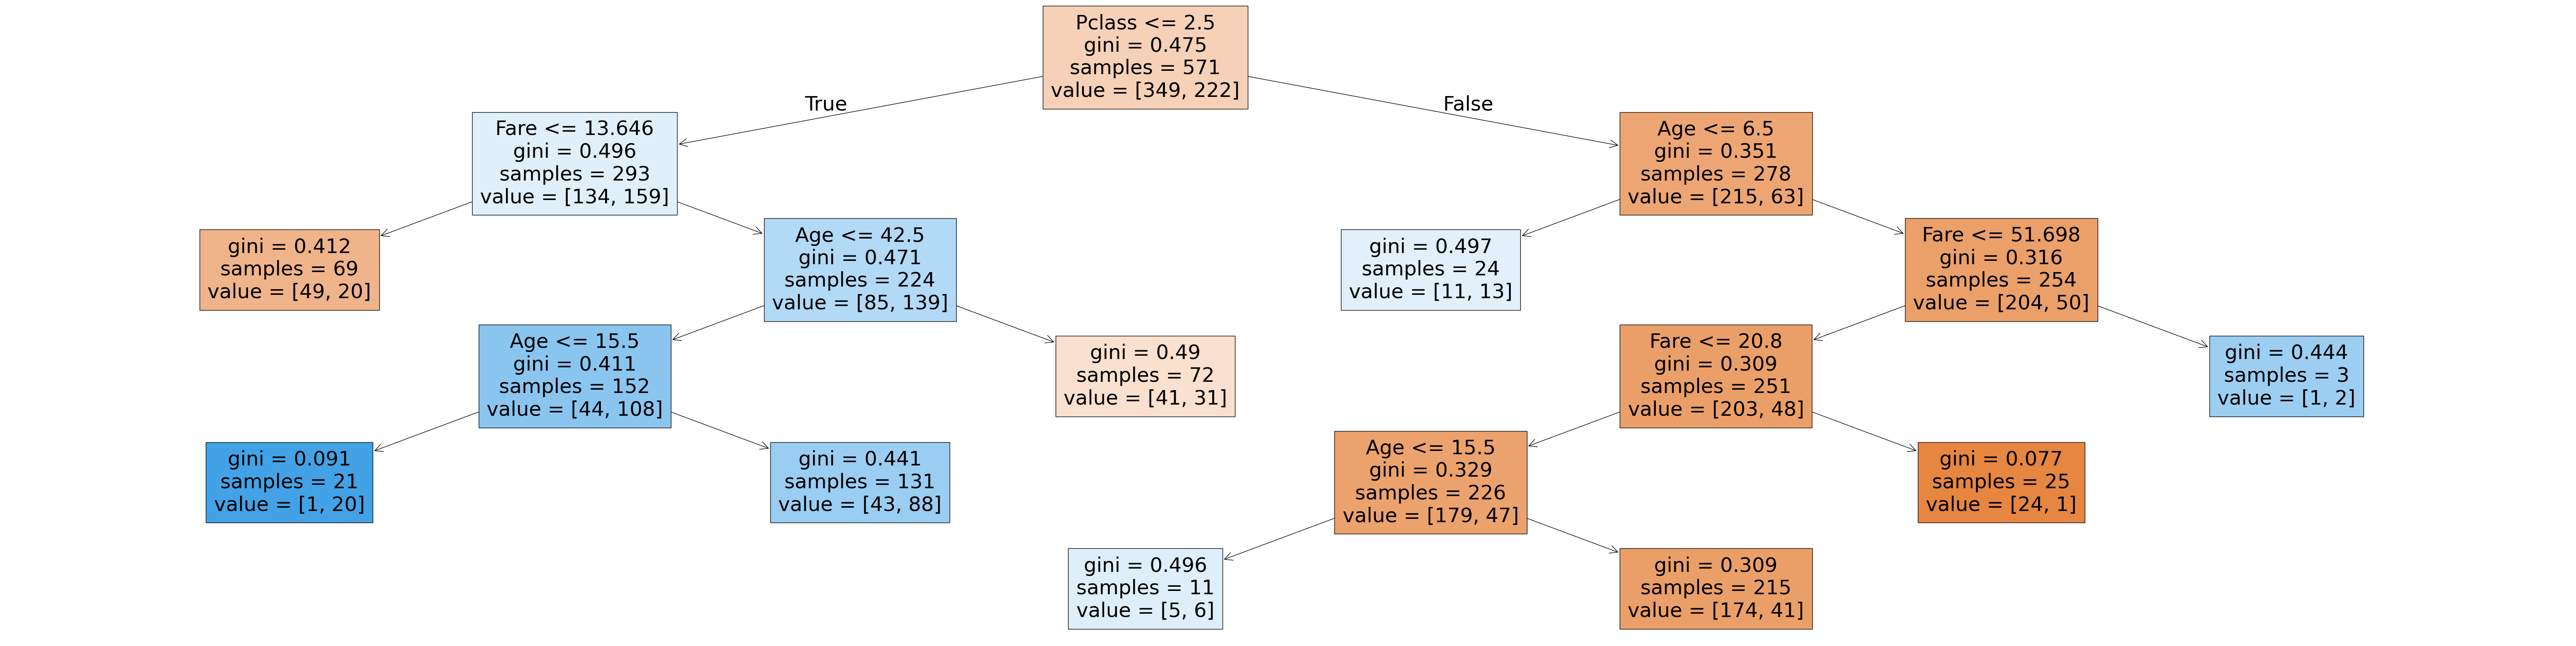

In [27]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=df.drop(columns='Survived').columns, max_depth=5, filled=True)


* Can you see how the model classifies a given input as a series of decisions?
* The tree is following any path from the root node down to a leaf will result in "Yes" or "No"

**How a Decision Tree is Created**

* Note the `gini` value in each box
* This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split
* A lower Gini index indicates a better split
* A perfect split (only one class on each side) has a Gini index of 0
* Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one
* Then, it recursively performs an optimal split for the two portions


#### Textual representation of our Decision Tree model

In [28]:
tree_text = export_text(model, max_depth=5, feature_names=df.drop(columns='Survived').columns)
print(tree_text)

|--- Pclass <= 2.50
|   |--- Fare <= 13.65
|   |   |--- class: 0
|   |--- Fare >  13.65
|   |   |--- Age <= 42.50
|   |   |   |--- Age <= 15.50
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  15.50
|   |   |   |   |--- class: 1
|   |   |--- Age >  42.50
|   |   |   |--- class: 0
|--- Pclass >  2.50
|   |--- Age <= 6.50
|   |   |--- class: 1
|   |--- Age >  6.50
|   |   |--- Fare <= 51.70
|   |   |   |--- Fare <= 20.80
|   |   |   |   |--- Age <= 15.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  15.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Fare >  20.80
|   |   |   |   |--- class: 0
|   |   |--- Fare >  51.70
|   |   |   |--- class: 1



#### Feature importance

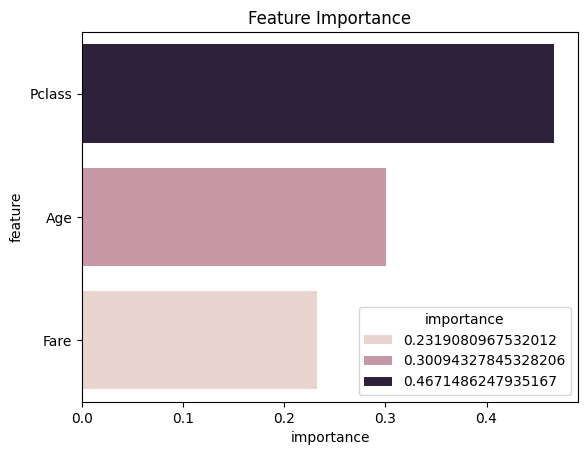

In [29]:
importance_df = pd.DataFrame({
    'feature': df.drop(columns='Survived').columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature', hue='importance')
plt.show()

### Hyperparameters, Underfitting and Overfitting
* Our decision tree classifier can memorise all training examples, leading to a 100% training accuracy (just like a student who memorised all possible exam answers)
* Yet validation accuracy will be very poor due to poor **generalisation**
* This phenomenon is called **overfitting**, and in this section, we'll have a closer look at it
* The `DecisionTreeClassifier` is a suitable model to demonstrate overfitting
* Overfitting is much more common than underfitting
* This is a common pattern you'll see with all machine learning algorithms:
<p align="center">
<img src="../assets/img/overfitting_vs_underfitting.jpg" width="600">
</p>


#### `max_depth` optimisation (example)

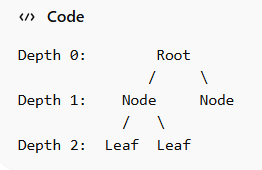

Maximum depth is:
* The maximum number of splits from the root to the deepest leaf
Or more formally:
* The longest path from the root node down to a leaf node

*Root = depth 0*

*First split = depth 1*

*Next split = depth 2*

*If the deepest leaf is at depth 2 → max_depth = 2.*

In [30]:
def max_depth_error(md):
    """
    Returns training and validation (test) accuracy as a function of tree maximum depth
    """
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(train.drop(columns='Survived'), train['Survived'])
    train_acc = 1 - model.score(train.drop(columns='Survived'), train['Survived'])
    test_acc = 1 - model.score(test.drop(columns='Survived'), test['Survived'])
    return {'Max Depth': md, 'Training Error': train_acc, 'Test Error': test_acc}

In [31]:
errors_list = []

for md in range(1, 21):
    result = max_depth_error(md)
    errors_list.append(result)

errors_df = pd.DataFrame(errors_list)

In [32]:
# errors_df
errors_df

,Max Depth,Training Error,Test Error
0,1,0.345009,0.293706
1,2,0.290718,0.286713
2,3,0.255692,0.314685
3,4,0.241681,0.314685
4,5,0.229422,0.300699
5,6,0.206655,0.314685
6,7,0.190893,0.370629
7,8,0.171629,0.370629
8,9,0.134851,0.370629
9,10,0.115587,0.377622


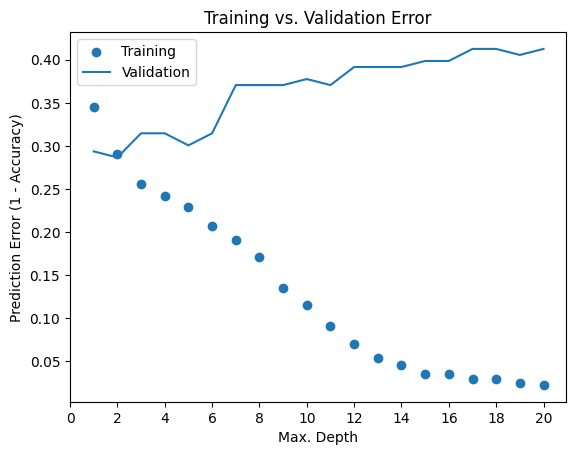

In [33]:
plt.figure()
plt.scatter(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Test Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.show()

In [34]:
?DecisionTreeClassifier

Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

In [35]:
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",150
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

---

## In-class exercise

---

##### Reminder: do not forget to **Clear All Outputs**
### Now you can commit and push your code to **GitHub**